## Curso Python para Economistas
### Trabajo Práctico 3

### Fecha de entrega:
Viernes 14/10 a las 17:00 hs (antes de la clase sincrónica 4)

### Modalidad de entrega y trabajo
- Este TP es de **trabajo individual**.
- Se debe entregar por vía de un repositorio **privado** de GitHub, al cual se le debe habilitar acceso a los 5 profesores. Los nombres de usuario son: `belenmichel`, `rbonazzola`,  `Queeno11`, `crisbonavida` y `borgojulian`.
- Antes de la fecha y hora de entrega pueden hacer cuantos cambios quieran en el repositorio, pero luego de la hora de corte no deben hacer más cambios, a menos que quieran usar los días de gracia.
- Recuerden comentar cada commit con un mensaje específico (esto es simplemente una buena práctica, pero no los evaluaremos por esto, sólo el mensaje final es obligatorio).  
- Al finalizar el trabajo práctico deben hacer un último commit en su repositorio de GitHub con el mensaje “Entrega final del TP3”.
- Cuando hayan hecho ese último commit, copien la URL para clonar su repositorio y péguenla en esta planilla de Google: https://docs.google.com/spreadsheets/d/1ipJF7Ja4Gzwys1Wy_OQPmXZ8YlzmdcaOsf63k3rhxaU/edit?usp=sharing. Al ser un repositorio privado, por más que publiquen el link, sólo los colaboradores habilitados podrán verlo/clonarlo.
- La última versión en el repositorio es la que será evaluada. Para esto es importante que no completen el Google Sheet hasta que no hayan finalizado el TP, como tampoco hacer pushes posteriores a la entrega. 

### Ejercicios

_Nota: recuerden que su código debe estar comentado donde corresponda. Además los gráficos deben ser prolijos, con títulos en cada eje, título principal y_ tick labels _legibles. El estilo de los mismos será evaluado en este trabajo práctico._

**(1)** Vamos a trabajar con el archivo `potencia_instalada_mod.csv`. (_Nota: van a tener que definir el parametro `encoding='latin1'`)_. Abrirlo y crear un dataframe que tenga las siguientes columnas:  
- `periodo`
- `agente`  
- `agente_descripcion`  
- `region`  
- `categoria_region`  
- `fuente_generacion`  
- `tecnologia`  
- `potencia_instalada_mw`  
  
y cortar la base para quedarnos únicamente con las primeras 11497 filas.

In [6]:
# Importo la librería pandas
import pandas as pd

# Abro archivo .csv y creo dataframe
df = pd.read_csv("potencia_instalada_mod.csv", encoding="latin1", sep="|", index_col="Unnamed: 0")

# Defino dataframe sólo con las columnas listadas
columnas = ["periodo", "agente", "agente_descripcion", "region", "categoria_region", "fuente_generacion", "tecnologia", "potencia_instalada_mw"]
df = df[columnas]

# Me quedo únicamente con las primeras 11.497 filas
df = df.head(11497)

# Renombro el índice
df.index.name = "indice"

# Inspecciono el dataframe
df

,periodo,agente,agente_descripcion,region,categoria_region,fuente_generacion,tecnologia,potencia_instalada_mw
indice,,,,,,,,
0,01/10/2015 0:00,CTBROWNG,C.T. ALMIRANTE BROWN,GRAN BS.AS.,Gba - Litoral - Buenos Aires,Térmica,Motor Diesel,25.00
1,01/10/2015 0:00,CAPEXSAG,C.T. AGUA DEL CAJON,COMAHUE,Comahue,Térmica,Ciclos Combinados,184.40
2,01/10/2015 0:00,HIDIAMAG,H. DIAMANTE SA,CUYO,Cuyo,Hidráulica,Hidráulica,150.00
3,01/10/2015 0:00,CTAESPAG,C.T. AES PARANA,BUENOS AIRES,Gba - Litoral - Buenos Aires,Térmica,Ciclos Combinados,525.96
4,01/10/2015 0:00,CTAESPAG,C.T. AES PARANA,BUENOS AIRES,Gba - Litoral - Buenos Aires,Térmica,Ciclos Combinados,319.30
...,...,...,...,...,...,...,...,...
11492,01/04/2019 0:00,CTENSENG,BIOGAS RS CT ENSENADA SECCO,GRAN BS.AS.,Gba - Litoral - Buenos Aires,Renovable,Biogas,5.30
11493,01/04/2019 0:00,CTAVELLG,BIOGAS CT AVELLANEDA SECCO,LITORAL,Gba - Litoral - Buenos Aires,Renovable,Biogas,6.30
11494,01/04/2019 0:00,PSTINO2G,PQUE SOLAR TINOGASTA II,NOROESTE,Noa,Renovable,Solar,7.00


**(2)** En la clase sincrónica vimos ejemplos de como transformar una columna a formato `datetime`, y como cambiar el estilo en el que se expresa un registro (convertir `1/10/2020` en `2020-10`). Repliquen este ejercicio sobre la columna `periodo` para crear una columna `periodo_limpio`. Luego inspeccionen el resultado. Si les dio como esperaban, ejecuten un comando de `.drop()` para eliminar la columna original.
  
_Nota: buscar documentación online y ejemplos en Stack Overflow puede ser útil_

In [7]:
# Creo una columna "periodo_limpio"
df["periodo_limpio"] = pd.to_datetime(df.periodo, format="%d/%m/%Y %H:%M").dt.strftime("%Y-%m")
df

# Elimino la columna original
df.drop("periodo", axis=1, inplace=True)

# Renombro columna "periodo_limpio"
df.rename(columns={"periodo_limpio":"periodo"}, inplace=True)

# Ordeno columnas
df = df[columnas]

# Inspecciono el dataframe
df

,periodo,agente,agente_descripcion,region,categoria_region,fuente_generacion,tecnologia,potencia_instalada_mw
indice,,,,,,,,
0,2015-10,CTBROWNG,C.T. ALMIRANTE BROWN,GRAN BS.AS.,Gba - Litoral - Buenos Aires,Térmica,Motor Diesel,25.00
1,2015-10,CAPEXSAG,C.T. AGUA DEL CAJON,COMAHUE,Comahue,Térmica,Ciclos Combinados,184.40
2,2015-10,HIDIAMAG,H. DIAMANTE SA,CUYO,Cuyo,Hidráulica,Hidráulica,150.00
3,2015-10,CTAESPAG,C.T. AES PARANA,BUENOS AIRES,Gba - Litoral - Buenos Aires,Térmica,Ciclos Combinados,525.96
4,2015-10,CTAESPAG,C.T. AES PARANA,BUENOS AIRES,Gba - Litoral - Buenos Aires,Térmica,Ciclos Combinados,319.30
...,...,...,...,...,...,...,...,...
11492,2019-04,CTENSENG,BIOGAS RS CT ENSENADA SECCO,GRAN BS.AS.,Gba - Litoral - Buenos Aires,Renovable,Biogas,5.30
11493,2019-04,CTAVELLG,BIOGAS CT AVELLANEDA SECCO,LITORAL,Gba - Litoral - Buenos Aires,Renovable,Biogas,6.30
11494,2019-04,PSTINO2G,PQUE SOLAR TINOGASTA II,NOROESTE,Noa,Renovable,Solar,7.00


**(3)** En la clases asincrónica y sincrónica vimos ejemplos de como agrupar información usando `.groupby()` y `.agg()`. Pongámoslo en práctica. Construyan un nuevo dataframe (con otro nombre para no pisar al original) donde el agrupamiento sea a nivel de periodo (la columna nueva) y tecnología. Ordenen el dataframe por fecha, en orden ascendente. Inspeccionen una muestra para ver que el resultado sea el esperado.
  

In [8]:
# Construyo un nuevo dataframe
df_groupby = df.groupby(by=["periodo", "tecnologia"]).agg({"potencia_instalada_mw": "sum"})

# Ordeno el dataframe por fecha (y tecnología) en orden ascendente
df_groupby.sort_values(by=["periodo", "tecnologia"], ascending=True, inplace=True)

# Defino los índices como columnas
df_groupby = df_groupby.reset_index()

# Inpsecciono el nuevo dataframe
df_groupby

,periodo,tecnologia,potencia_instalada_mw
0,2015-10,Biogas,16.600
1,2015-10,Ciclos Combinados,9227.130
2,2015-10,Eólica,187.350
3,2015-10,Hidráulica,11107.290
4,2015-10,Micro Hidráulica,0.650
...,...,...,...
375,2019-04,Motor Diesel,1808.046
376,2019-04,Nuclear,1755.000
377,2019-04,Solar,301.630
378,2019-04,Turbina a gas,7091.328


**(4)** Ahora ejercitemos `matplotlib.pyplot`: importen la librería y construyan un gráfico de barras que muestre en el eje x el periodo y en el eje y la potencia instalada para una tecnología de su elección. El título del gráfico debe incluir la tecnología elegida y los ejes deben estar titulados.  
  
  
_Nota: No vimos como armar un gráfico de barras en clase pero la estructura es similar a los ejemplos que sí vimos. Parte de este ejercicio es practicar buscar cómo hacerlo en la documentación oficial y/u otros recursos online. Hay una comunidad grande de personas usando Python!_

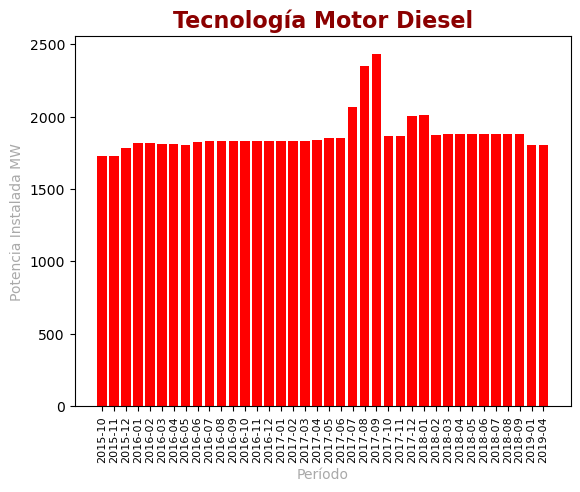

In [9]:
# Importo la librería matplotlib.pyplot
import matplotlib.pyplot as plt

# Defino vectores de datos
y = df_groupby[df_groupby["tecnologia"]=="Motor Diesel"]["potencia_instalada_mw"]
x = df_groupby[df_groupby["tecnologia"]=="Motor Diesel"]["periodo"]

# Creo gráfico de barras con matplotlib
plt.bar(x, y, color="red")
plt.title("Tecnología Motor Diesel", color="darkred", size=16, weight="bold")
plt.ylabel("Potencia Instalada MW", color="darkgrey")
plt.xlabel("Período", color="darkgrey")
plt.xticks(ticks=x, rotation=90, size=8)
plt.show()

**(5)** Para seguir ejercitando `matplotlib`, construyan una figura con 4 gráficos de la potencia instalada por energía a lo largo el periodo, en una disposición de 2x2. Que por lo menos un gráfico sea de línea y por lo menos un gráfico sea de barra. Los otros dos gráficos pueden ser uno de línea y otro de barra o lo que ustedes quieran probar. Lo importante es practicar graficar y que el gráfico sea razonable. Si quieren que alguno de los gráficos muestre algo distinto de la evolución temporal de la potencia instalada, no hay problema.

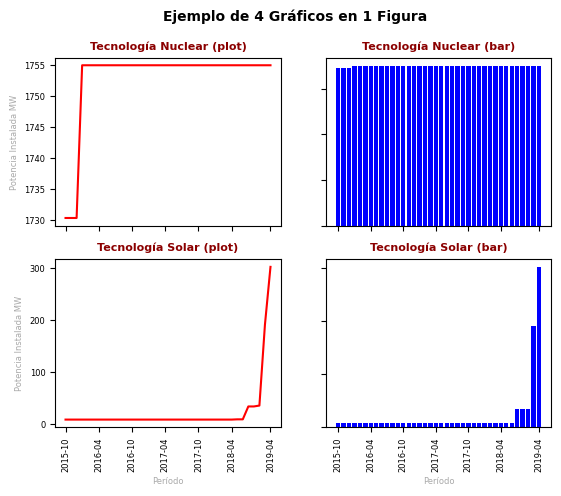

In [10]:
# Defino vectores de datos
y1 = df_groupby[df_groupby["tecnologia"]=="Nuclear"]["potencia_instalada_mw"]
x1 = df_groupby[df_groupby["tecnologia"]=="Nuclear"]["periodo"]
y2 = df_groupby[df_groupby["tecnologia"]=="Solar"]["potencia_instalada_mw"]
x2 = df_groupby[df_groupby["tecnologia"]=="Solar"]["periodo"]

# Defino lista con menos períodos que los del dataframe (para hacer más amena la figura)
tick_list = ["2015-10","2016-04","2016-10","2017-04","2017-10","2018-04","2019-04"]

# Creo 4 gráficos en 1 figura con matplotlib

fig, axs = plt.subplots(2, 2)

plt.suptitle("Ejemplo de 4 Gráficos en 1 Figura", color="black", size=10, weight="bold")

axs[0, 0].plot(x1, y1, color="red")
axs[0, 0].set_title("Tecnología Nuclear (plot)", color="darkred", size=8, weight="bold")
axs[0, 1].bar(x1, y1, color="blue")
axs[0, 1].set_title("Tecnología Nuclear (bar)", color="darkred", size=8, weight="bold")
axs[1, 0].plot(x2, y2, color="red")
axs[1, 0].set_title("Tecnología Solar (plot)", color="darkred", size=8, weight="bold")
axs[1, 1].bar(x2, y2, color="blue")
axs[1, 1].set_title("Tecnología Solar (bar)", color="darkred", size=8, weight="bold")

for ax in axs.flat:
    ax.set_ylabel("Potencia Instalada MW", color="darkgrey", size=6)  # nombro ylabel
    ax.set_xlabel("Período", color="darkgrey", size=6)                # nombro ylabel
    ax.set_xticks(tick_list)                                          # muestro sólo las xticks de la tick_list
    for ytick in ax.get_yticklabels():                                # edito las yticklabels
        ytick.set_size(6)
    for xtick in ax.get_xticklabels():                                # edito las xticklabels
        xtick.set_rotation(90)
        xtick.set_size(6)
    ax.label_outer()                                                  # muestro sólo una vez por filas y por columnas las ylabels y xlabels, respectivamente

plt.show()

**(6)** Armen una figura con un gráfico que combine dos representaciones de datos de su elección. Podría ser combinar un gráfico de barras con uno de líneas, donde el eje vertical izquierdo muestre los valores de uno y el eje vertical derecho muestre los valores del otro. Por ejemplo que en el gráfico las barras muestren la variación de potencia instalada respecto al periodo pasado y una línea muestre la evolución de potencia instalada. _Nota: van a tener que trabajar sobre el dataframe para esto, la función `.shift()` aplicada a la columna de potencia instalada les puede ser útil como paso intermedio para calcular el crecimiento porcentual_.

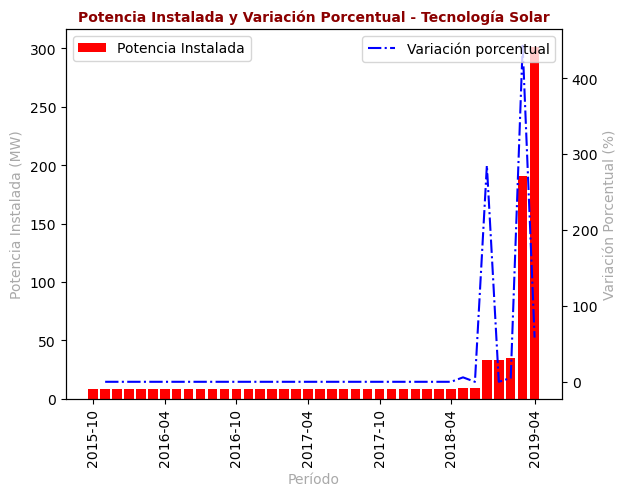

In [11]:
# Creo columna con variación porcentual (por tecnología) de potencia_instalada_mw respecto al período pasado
df_groupby["var_porc"] = (df_groupby["potencia_instalada_mw"] / df_groupby.groupby(by="tecnologia")["potencia_instalada_mw"].shift(1) - 1) * 100
df_groupby

# Defino vectores de datos
y1 = df_groupby[df_groupby["tecnologia"]=="Solar"]["potencia_instalada_mw"]
y2 = df_groupby[df_groupby["tecnologia"]=="Solar"]["var_porc"]
x  = df_groupby[df_groupby["tecnologia"]=="Solar"]["periodo"]

# Defino lista con menos períodos que los del dataframe (para hacer más amena la figura)
tick_list = ["2015-10","2016-04","2016-10","2017-04","2017-10","2018-04","2019-04"]

# Creo gráfico combinado con matplotlib

fig, ax1 = plt.subplots()
ax1.bar(x, y1, label="Potencia Instalada", color="red")
ax1.set_ylabel("Potencia Instalada (MW)", color="darkgrey")
ax1.set_xlabel("Período", color="darkgrey")
ax1.legend(loc="upper left")

ax2 = ax1.twinx()
ax2.plot(x, y2, label="Variación porcentual", color="blue", linestyle="-.")
ax2.set_ylabel("Variación Porcentual (%)", color="darkgrey")
ax2.legend(loc="upper right")

plt.title("Potencia Instalada y Variación Porcentual - Tecnología Solar", color="darkred", size=10, weight="bold")

ax1.set_xticks(tick_list)
for xtick in ax1.get_xticklabels():
    xtick.set_rotation(90)

plt.show()

**(7)** En este ejercicio les pedimos que busquen en la documentación de `matplotlib` las diferentes opciones de gráficos disponibles. Armen un gráfico distinto a lo que hayan aplicado en los ejercicios anteriores.

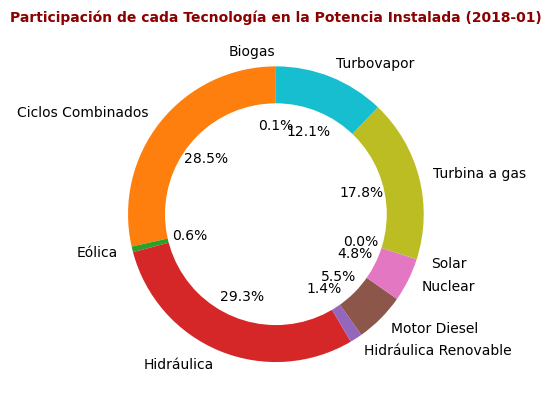

In [12]:
# Defino vectores de datos
x = df_groupby[df_groupby["periodo"]=="2018-01"]["potencia_instalada_mw"]
y = df_groupby[df_groupby["periodo"]=="2018-01"]["tecnologia"]

# Creo un gráfico "pie" con matplotlib
plt.pie(x, labels=y, autopct="%.1f%%", startangle=90)
plt.title("Participación de cada Tecnología en la Potencia Instalada (2018-01)", color="darkred", size=10, weight="bold")
circle = plt.Circle(xy=(0,0), radius=.75, facecolor="white")
plt.gca().add_artist(circle)
plt.show()